In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración para mejores visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# 1. Descripción del Dataset

Esta sección proporciona una descripción completa del conjunto de datos de Pronóstico de Ventas de Tiendas Walmart.


In [2]:
# Cargar los conjuntos de datos
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
stores_df = pd.read_csv('data/stores.csv')
features_df = pd.read_csv('data/features.csv')

# Mostrar información básica
print("Pronóstico de Ventas de Tiendas Walmart - Resumen del Dataset")
print("\nTamaños de los Datasets:")
print(f"- Conjunto de entrenamiento: {train_df.shape[0]:,} filas × {train_df.shape[1]} columnas")
print(f"- Conjunto de prueba: {test_df.shape[0]:,} filas × {test_df.shape[1]} columnas")
print(f"- Información de tiendas: {stores_df.shape[0]} tiendas")
print(f"- Dataset de características: {features_df.shape[0]:,} filas × {features_df.shape[1]} columnas")


Pronóstico de Ventas de Tiendas Walmart - Resumen del Dataset

Tamaños de los Datasets:
- Conjunto de entrenamiento: 421,570 filas × 5 columnas
- Conjunto de prueba: 115,064 filas × 4 columnas
- Información de tiendas: 45 tiendas
- Dataset de características: 8,190 filas × 12 columnas


## 1.1 Fuente de Datos y Contexto

**Fuente:** Competencia Kaggle - Walmart Recruiting: Store Sales Forecasting  
**URL:** https://www.kaggle.com/competitions/walmart-recruiting-store-sales-forecasting

**Contexto:**  
Walmart es una corporación minorista líder que opera una cadena de hipermercados, tiendas departamentales de descuento y tiendas de comestibles. Este conjunto de datos fue publicado como parte de una competencia de reclutamiento para predecir las ventas de cada departamento por tienda para el siguiente año.

**Período de Tiempo:**  
- Datos de entrenamiento: 5 de febrero de 2010 - 1 de noviembre de 2012 (aproximadamente 2.75 años)
- Datos de prueba: 2 de noviembre de 2012 - 26 de julio de 2013 (aproximadamente 9 meses)

**Objetivo:**  
Predecir las ventas semanales de 45 tiendas Walmart ubicadas en diferentes regiones, considerando el impacto de eventos promocionales de descuento (markdown) y días festivos en los patrones de ventas.


In [3]:
# Mostrar las primeras filas de cada dataset
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
stores_df.head(10)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [5]:
features_df.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


## 1.2 Descripción de Variables (Características X y Variable Objetivo y)

El conjunto de datos está dividido en cuatro archivos. Para el análisis exploratorio, tres archivos se fusionan (train.csv, stores.csv y features.csv), mientras que test.csv se utiliza después para las predicciones finales.


### 1.2.1 train.csv - Conjunto de Entrenamiento

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


**Descripciones de columnas:**

- Store: Número de tienda (1-45)
- Dept: Número de departamento dentro de cada tienda
- Date: Fecha de la semana
- Weekly_Sales: Ventas del departamento en la tienda dada (variable objetivo)
- IsHoliday: Booleano que indica si la semana es una semana festiva especial


### 1.2.2 test.csv - Conjunto de Prueba


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB


**Descripciones de columnas:**

- Store: Número de tienda (1-45)
- Dept: Número de departamento dentro de cada tienda
- Date: Fecha de la semana
- IsHoliday: Booleano que indica si la semana es una semana festiva especial

**Nota:** Este conjunto no incluye Weekly_Sales ya que es el objetivo a predecir.

### 1.2.3 stores.csv - Información de Tiendas

In [8]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


**Descripciones de columnas:**

- Store: Número de tienda
- Type: Tipo de tienda (A, B, o C) - probablemente relacionado con tamaño/formato de tienda
- Size: Tamaño de la tienda en pies cuadrados


### 1.2.4 features.csv - Características Adicionales

In [9]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


**Descripciones de columnas:**

- Store: Número de tienda
- Date: Fecha de la semana
- Temperature: Temperatura promedio en la región (Fahrenheit)
- Fuel_Price: Costo del combustible en la región
- MarkDown1-5: Datos anonimizados relacionados con descuentos promocionales
- CPI: Índice de Precios al Consumidor
- Unemployment: Tasa de desempleo en la región
- IsHoliday: Booleano que indica si la semana es una semana festiva especial


## 1.3 Tabla Resumen del Dataset


In [10]:
# Crear tabla resumen completa
summary_data = {
    'Variable': ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 
                 'Temperature', 'Fuel_Price', 'MarkDown1-5', 'CPI', 'Unemployment'],
    'Tipo': ['Entero', 'Entero', 'Fecha', 'Continua', 'Booleano', 'Categórica', 'Entero',
             'Continua', 'Continua', 'Continua', 'Continua', 'Continua'],
    'Descripción': [
        'Identificador de tienda (1-45)',
        'Identificador de departamento dentro de la tienda',
        'Fecha de fin de semana',
        'OBJETIVO: Ventas semanales del departamento en la tienda',
        'Indicador de semana festiva especial',
        'Tipo de tienda: A, B, o C',
        'Tamaño de tienda en pies cuadrados',
        'Temperatura promedio regional (°F)',
        'Costo regional del combustible',
        'Datos de descuentos promocionales (5 características)',
        'Índice de Precios al Consumidor',
        'Tasa de desempleo regional (%)'
    ],
    'Fuente': ['train/test', 'train/test', 'todos', 'solo train', 'todos', 'stores', 'stores',
               'features', 'features', 'features', 'features', 'features'],
    'Rol': ['Característica', 'Característica', 'Característica', 'Objetivo', 'Característica', 
            'Característica', 'Característica', 'Característica', 'Característica', 
            'Característica', 'Característica', 'Característica']
}

summary_df = pd.DataFrame(summary_data)
summary_df


,Variable,Tipo,Descripción,Fuente,Rol
0,Store,Entero,Identificador de tienda (1-45),train/test,Característica
1,Dept,Entero,Identificador de departamento dentro de la tienda,train/test,Característica
2,Date,Fecha,Fecha de fin de semana,todos,Característica
3,Weekly_Sales,Continua,OBJETIVO: Ventas semanales del departamento en...,solo train,Objetivo
4,IsHoliday,Booleano,Indicador de semana festiva especial,todos,Característica
5,Type,Categórica,"Tipo de tienda: A, B, o C",stores,Característica
6,Size,Entero,Tamaño de tienda en pies cuadrados,stores,Característica
7,Temperature,Continua,Temperatura promedio regional (°F),features,Característica
8,Fuel_Price,Continua,Costo regional del combustible,features,Característica
9,MarkDown1-5,Continua,Datos de descuentos promocionales (5 caracterí...,features,Característica


In [11]:
# Estadísticas adicionales del dataset
print("Estadísticas Adicionales del Dataset:\n")
print(f"- Número de tiendas únicas: {train_df['Store'].nunique()}")
print(f"- Número de departamentos únicos: {train_df['Dept'].nunique()}")
print(f"\nDistribución de tipos de tienda:")
print(stores_df['Type'].value_counts())
print(f"\nRango de fechas en datos de entrenamiento (train.csv):")
print(f"- Inicio: {train_df['Date'].min()}")
print(f"- Fin: {train_df['Date'].max()}")
print(f"\nRango de fechas en datos de prueba (test.csv):")
print(f"- Inicio: {test_df['Date'].min()}")
print(f"- Fin: {test_df['Date'].max()}")

Estadísticas Adicionales del Dataset:

- Número de tiendas únicas: 45
- Número de departamentos únicos: 81

Distribución de tipos de tienda:
Type
A    22
B    17
C     6
Name: count, dtype: int64

Rango de fechas en datos de entrenamiento (train.csv):
- Inicio: 2010-02-05
- Fin: 2012-10-26

Rango de fechas en datos de prueba (test.csv):
- Inicio: 2012-11-02
- Fin: 2013-07-26


# 2. Análisis Exploratorio de Datos (EDA)

En esta sección, realizamos un análisis exploratorio completo para comprender la distribución de datos, relaciones y calidad.


In [12]:
# Fusionar todos los datasets para análisis completo
# Primero, fusionar train con stores
train_merged = train_df.merge(stores_df, on='Store', how='left')

# Luego fusionar con features
train_full = train_merged.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

# Convertir Date a datetime
train_full['Date'] = pd.to_datetime(train_full['Date'])

# Extraer características basadas en tiempo
train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['Week'] = train_full['Date'].dt.isocalendar().week
train_full['Quarter'] = train_full['Date'].dt.quarter

print(f"Forma del dataset fusionado: {train_full.shape}")
train_full.head()


Forma del dataset fusionado: (421570, 20)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5,1
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,6,1
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,7,1
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,8,1
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,9,1


## 2.1 Análisis de Valores Faltantes


In [13]:
# Verificar valores faltantes
missing_values = train_full.isnull().sum()
missing_percentage = (missing_values / len(train_full)) * 100

missing_df = pd.DataFrame({
    'Cantidad_Faltante': missing_values,
    'Porcentaje': missing_percentage
}).sort_values(by='Cantidad_Faltante', ascending=False)

missing_df = missing_df[missing_df['Cantidad_Faltante'] > 0]

print("Resumen de Valores Faltantes:\n")
print(missing_df)


Resumen de Valores Faltantes:

           Cantidad_Faltante  Porcentaje
MarkDown2             310322   73.611025
MarkDown4             286603   67.984676
MarkDown3             284479   67.480845
MarkDown1             270889   64.257181
MarkDown5             270138   64.079038


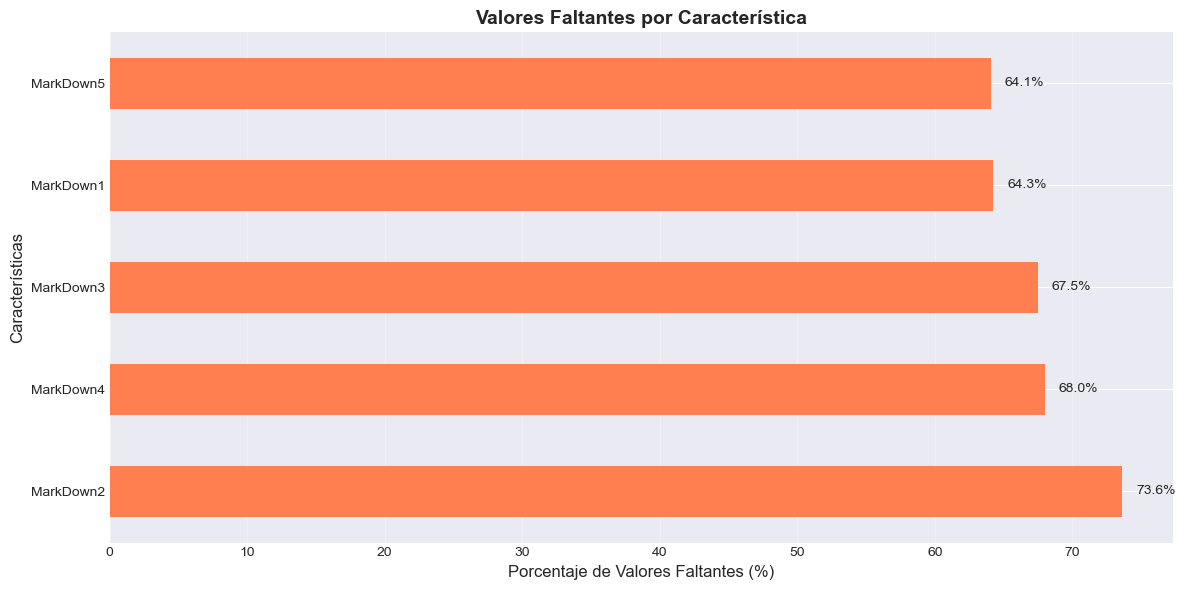

In [14]:
# Visualizar valores faltantes
fig, ax = plt.subplots(figsize=(12, 6))
missing_df.plot(kind='barh', y='Porcentaje', ax=ax, color='coral', legend=False)
ax.set_xlabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
ax.set_ylabel('Características', fontsize=12)
ax.set_title('Valores Faltantes por Característica', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(missing_df['Porcentaje']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


**Estrategia para Manejo de Valores Faltantes:**

1. **MarkDown1-5**: Estas características tienen valores faltantes significativos (>50%). Los valores faltantes probablemente indican semanas sin descuentos promocionales. Estrategia: Rellenar con 0 (sin descuento).

2. **CPI y Unemployment**: Pequeño porcentaje de valores faltantes (<1%). Estrategia: Rellenado hacia adelante o interpolación basada en continuidad temporal.


## 2.2 Distribución de la Variable Objetivo (Weekly_Sales)


In [15]:
# Resumen estadístico de la variable objetivo
print("Estadísticas de Ventas Semanales:\n")
print(train_full['Weekly_Sales'].describe())
print("\nEstadísticas adicionales:")
print(f"- Asimetría (Skewness): {train_full['Weekly_Sales'].skew():.4f}")
print(f"- Curtosis (Kurtosis): {train_full['Weekly_Sales'].kurtosis():.4f}")
print(f"- Número de ventas negativas: {(train_full['Weekly_Sales'] < 0).sum()}")


Estadísticas de Ventas Semanales:

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

Estadísticas adicionales:
- Asimetría (Skewness): 3.2620
- Curtosis (Kurtosis): 21.4913
- Número de ventas negativas: 1285


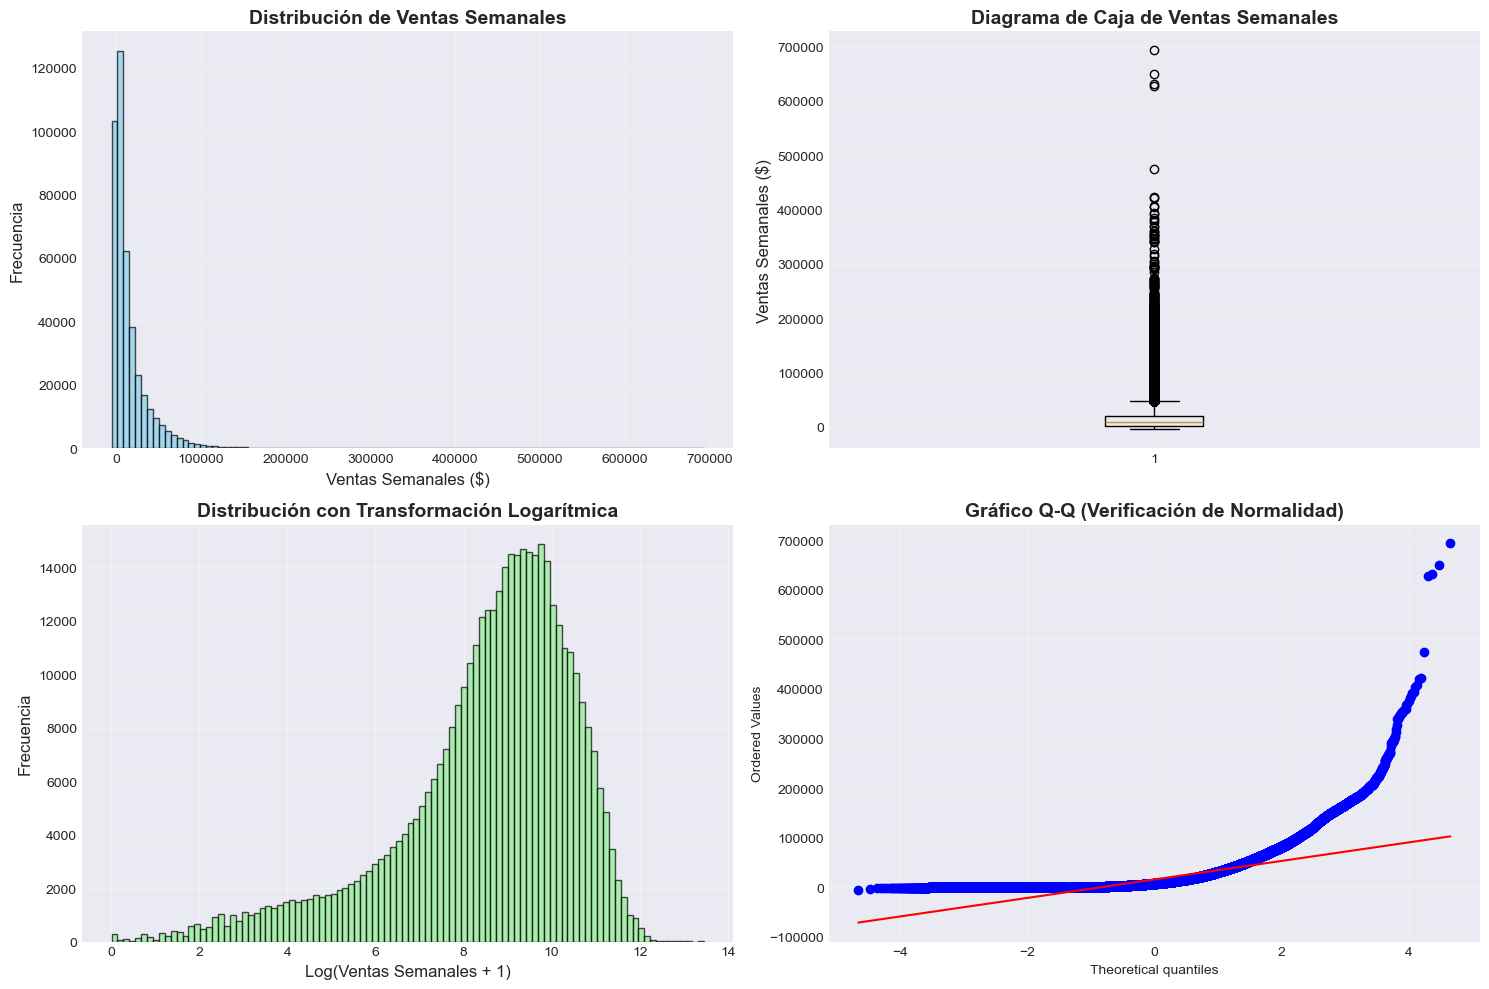

In [16]:
# Visualización de distribución
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma
axes[0, 0].hist(train_full['Weekly_Sales'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Ventas Semanales ($)', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].set_title('Distribución de Ventas Semanales', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Diagrama de caja
axes[0, 1].boxplot(train_full['Weekly_Sales'], vert=True)
axes[0, 1].set_ylabel('Ventas Semanales ($)', fontsize=12)
axes[0, 1].set_title('Diagrama de Caja de Ventas Semanales', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Histograma con transformación logarítmica (para ver mejor la distribución)
axes[1, 0].hist(np.log1p(train_full[train_full['Weekly_Sales'] > 0]['Weekly_Sales']), 
                bins=100, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Log(Ventas Semanales + 1)', fontsize=12)
axes[1, 0].set_ylabel('Frecuencia', fontsize=12)
axes[1, 0].set_title('Distribución con Transformación Logarítmica', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gráfico Q-Q para verificar normalidad
from scipy import stats
stats.probplot(train_full['Weekly_Sales'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Gráfico Q-Q (Verificación de Normalidad)', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2.3 Distribución de Características Clave


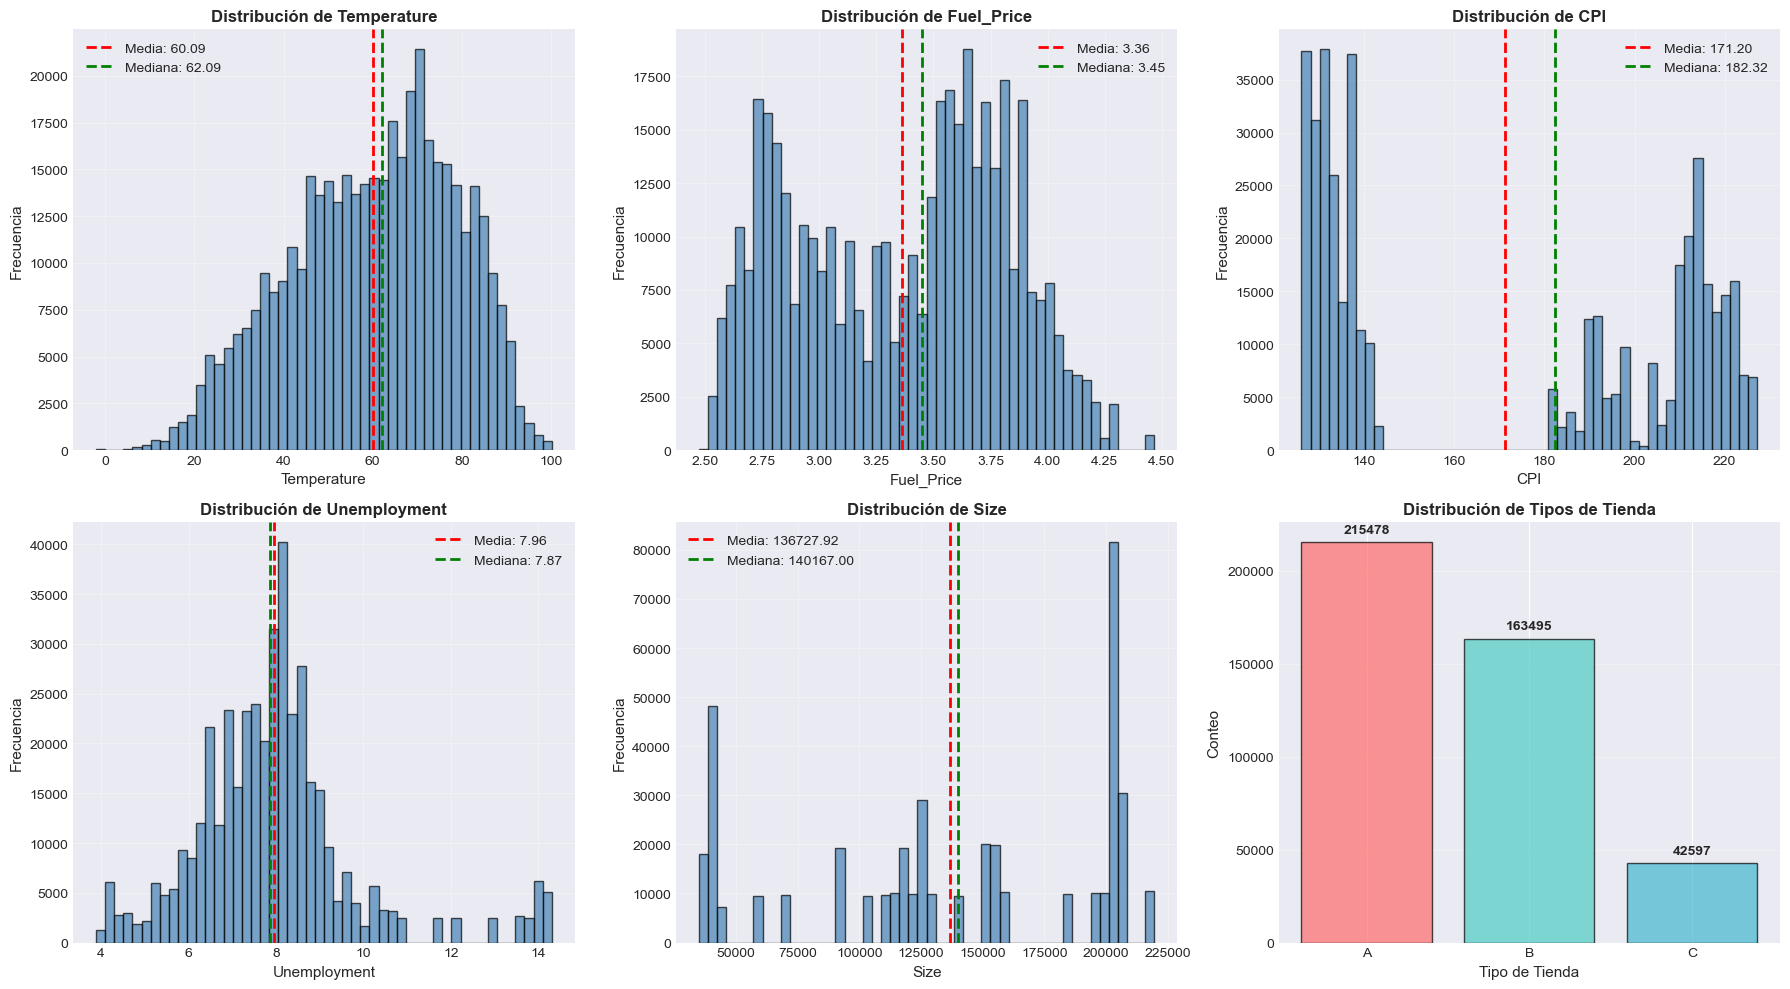

In [17]:
# Seleccionar características numéricas para análisis de distribución
numerical_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    # Remover valores NaN para graficar
    data = train_full[feature].dropna()
    
    # Histograma
    axes[idx].hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frecuencia', fontsize=11)
    axes[idx].set_title(f'Distribución de {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    
    # Añadir estadísticas
    mean_val = data.mean()
    median_val = data.median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
    axes[idx].legend()

# Distribución de Tipo de Tienda (categórica)
type_counts = train_full['Type'].value_counts()
axes[5].bar(type_counts.index, type_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', alpha=0.7)
axes[5].set_xlabel('Tipo de Tienda', fontsize=11)
axes[5].set_ylabel('Conteo', fontsize=11)
axes[5].set_title('Distribución de Tipos de Tienda', fontsize=12, fontweight='bold')
axes[5].grid(alpha=0.3, axis='y')

for i, (type_name, count) in enumerate(type_counts.items()):
    axes[5].text(i, count + 5000, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


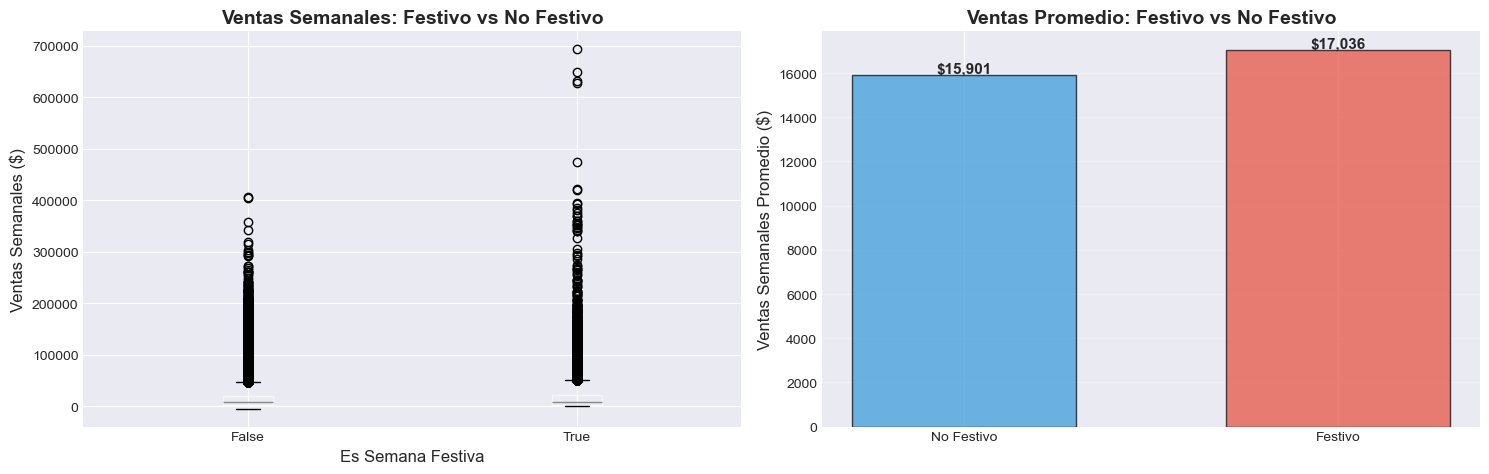

In [18]:
# Ventas en Días Festivos vs No Festivos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Comparación con diagrama de caja
train_full.boxplot(column='Weekly_Sales', by='IsHoliday', ax=axes[0])
axes[0].set_xlabel('Es Semana Festiva', fontsize=12)
axes[0].set_ylabel('Ventas Semanales ($)', fontsize=12)
axes[0].set_title('Ventas Semanales: Festivo vs No Festivo', fontsize=14, fontweight='bold')
axes[0].get_figure().suptitle('')

# Gráfico de barras de ventas promedio
holiday_sales = train_full.groupby('IsHoliday')['Weekly_Sales'].mean()
colors = ['#3498db', '#e74c3c']
bars = axes[1].bar(['No Festivo', 'Festivo'], holiday_sales.values, color=colors, edgecolor='black', alpha=0.7, width=0.6)
axes[1].set_ylabel('Ventas Semanales Promedio ($)', fontsize=12)
axes[1].set_title('Ventas Promedio: Festivo vs No Festivo', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

for bar, val in zip(bars, holiday_sales.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 2.4 Análisis de Correlación


In [19]:
# Seleccionar columnas numéricas para análisis de correlación
numerical_cols = ['Weekly_Sales', 'Store', 'Dept', 'Size', 'Temperature', 
                  'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Quarter']

# Crear matriz de correlación (solo en casos completos)
correlation_data = train_full[numerical_cols].dropna()
correlation_matrix = correlation_data.corr()

# Correlación con la variable objetivo
target_corr = correlation_matrix['Weekly_Sales'].sort_values(ascending=False)
print("Correlación con Weekly_Sales:\n")
print(target_corr)

Correlación con Weekly_Sales:

Weekly_Sales    1.000000
Size            0.243828
Dept            0.148032
Month           0.028409
Quarter         0.023838
Fuel_Price     -0.000120
Temperature    -0.002312
Year           -0.010111
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64


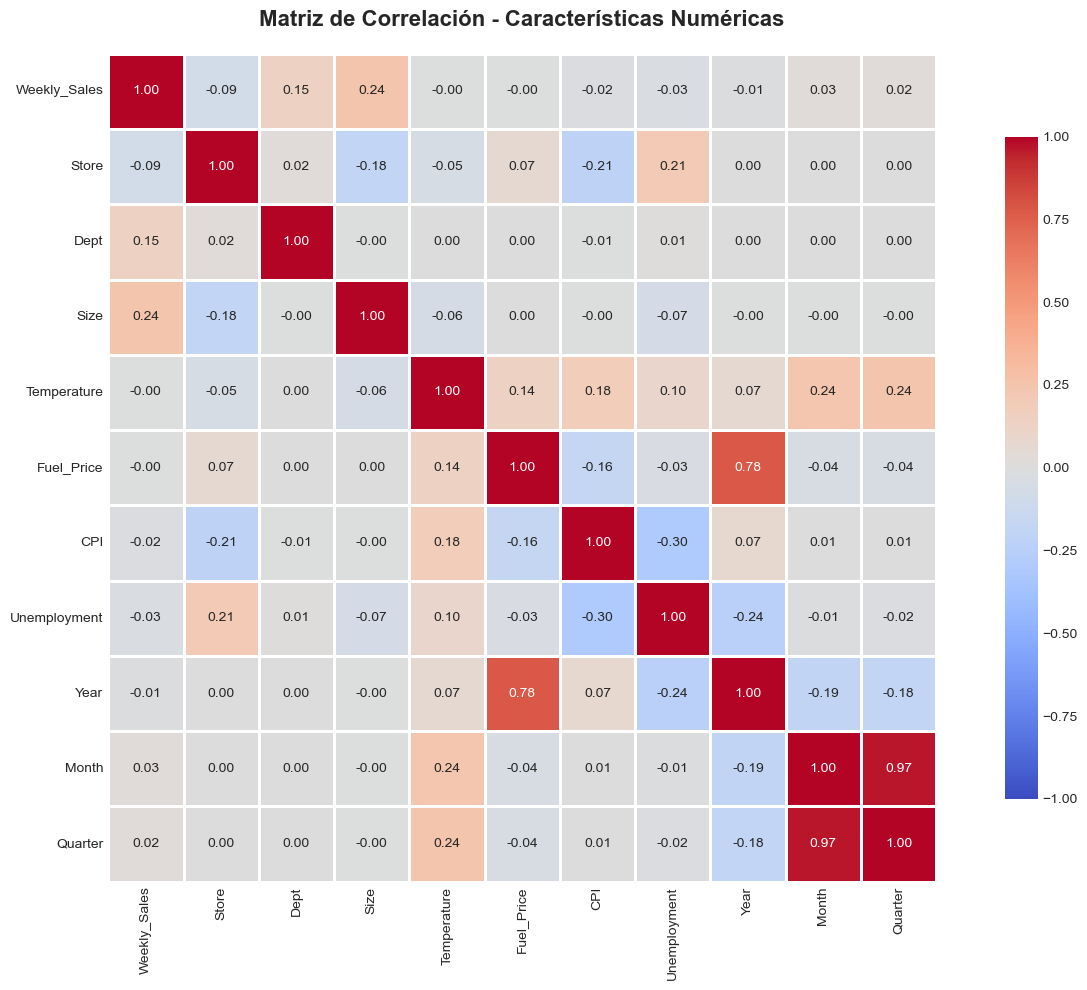

In [20]:
# Mapa de calor de la matriz de correlación
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Matriz de Correlación - Características Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [21]:
# Verificar multicolinealidad usando VIF (Factor de Inflación de Varianza)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preparar datos para cálculo de VIF
vif_data = correlation_data.drop('Weekly_Sales', axis=1).dropna()

# Calcular VIF para cada característica
vif_results = pd.DataFrame()
vif_results['Característica'] = vif_data.columns
vif_results['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif_results = vif_results.sort_values('VIF', ascending=False)

print("\nFactor de Inflación de Varianza (VIF) - Verificación de Multicolinealidad:\n")
print("Nota: VIF > 10 indica alta multicolinealidad\n")
print(vif_results)



Factor de Inflación de Varianza (VIF) - Verificación de Multicolinealidad:

Nota: VIF > 10 indica alta multicolinealidad

  Característica         VIF
7           Year  153.365360
9        Quarter   99.297529
8          Month   76.740555
4     Fuel_Price   60.072882
5            CPI   25.111029
6   Unemployment   22.798217
3    Temperature   13.907648
2           Size    6.282312
0          Store    4.479023
1           Dept    3.108922


## 2.5 Detección y Análisis de Valores Atípicos


In [22]:
# Detección de valores atípicos usando el método IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detectar valores atípicos en Weekly_Sales
outliers_sales, lower_sales, upper_sales = detect_outliers_iqr(train_full, 'Weekly_Sales')

print("Análisis de Valores Atípicos para Weekly_Sales:\n")
print(f"- Total de registros: {len(train_full):,}")
print(f"- Número de valores atípicos: {len(outliers_sales):,} ({len(outliers_sales)/len(train_full)*100:.2f}%)")
print(f"- Límite inferior: ${lower_sales:,.2f}")
print(f"- Límite superior: ${upper_sales:,.2f}")
print(f"- Valor mínimo: ${train_full['Weekly_Sales'].min():,.2f}")
print(f"- Valor máximo: ${train_full['Weekly_Sales'].max():,.2f}")

Análisis de Valores Atípicos para Weekly_Sales:

- Total de registros: 421,570
- Número de valores atípicos: 35,521 (8.43%)
- Límite inferior: $-25,109.65
- Límite superior: $47,395.16
- Valor mínimo: $-4,988.94
- Valor máximo: $693,099.36


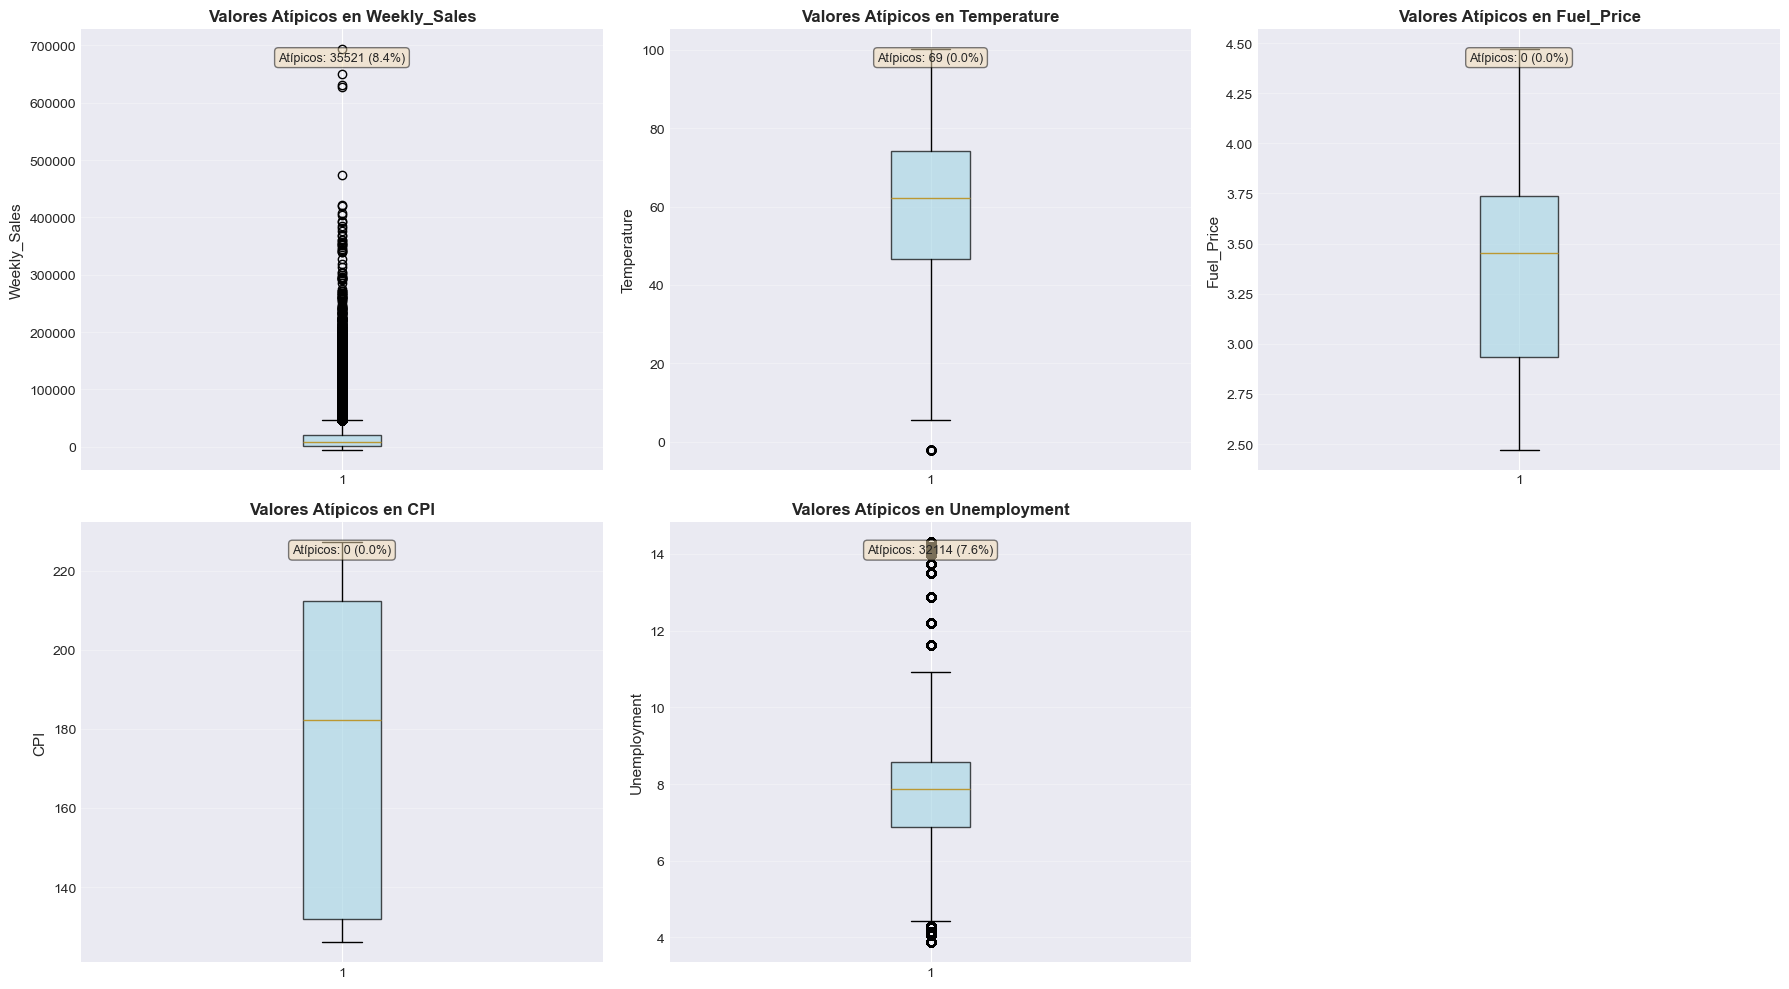

In [23]:
# Visualizar valores atípicos en diferentes características
features_to_check = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_check):
    data = train_full[feature].dropna()
    
    # Diagrama de caja
    bp = axes[idx].boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].set_title(f'Valores Atípicos en {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Añadir estadísticas
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    
    axes[idx].text(0.5, 0.95, f'Atípicos: {n_outliers} ({n_outliers/len(data)*100:.1f}%)', 
                  transform=axes[idx].transAxes, ha='center', va='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

# Eliminar subplot extra
axes[5].remove()

plt.tight_layout()
plt.show()

**Estrategia de Tratamiento de Valores Atípicos:**

Dado que estos son datos de ventas minoristas:
1. **Ventas negativas**: Representan devoluciones y son eventos comerciales validos - mantenerlos
2. **Ventas muy altas**: A menudo ocurren durante días festivos o eventos especiales - son validos e importantes para el modelo
3. **Ventas muy bajas**: Pueden representar departamentos nuevos o períodos de liquidación - también validos

Es importante mantener los valores atípicos ya que representan escenarios comerciales reales que el modelo necesita aprender.


## 2.6 Análisis de Series Temporales


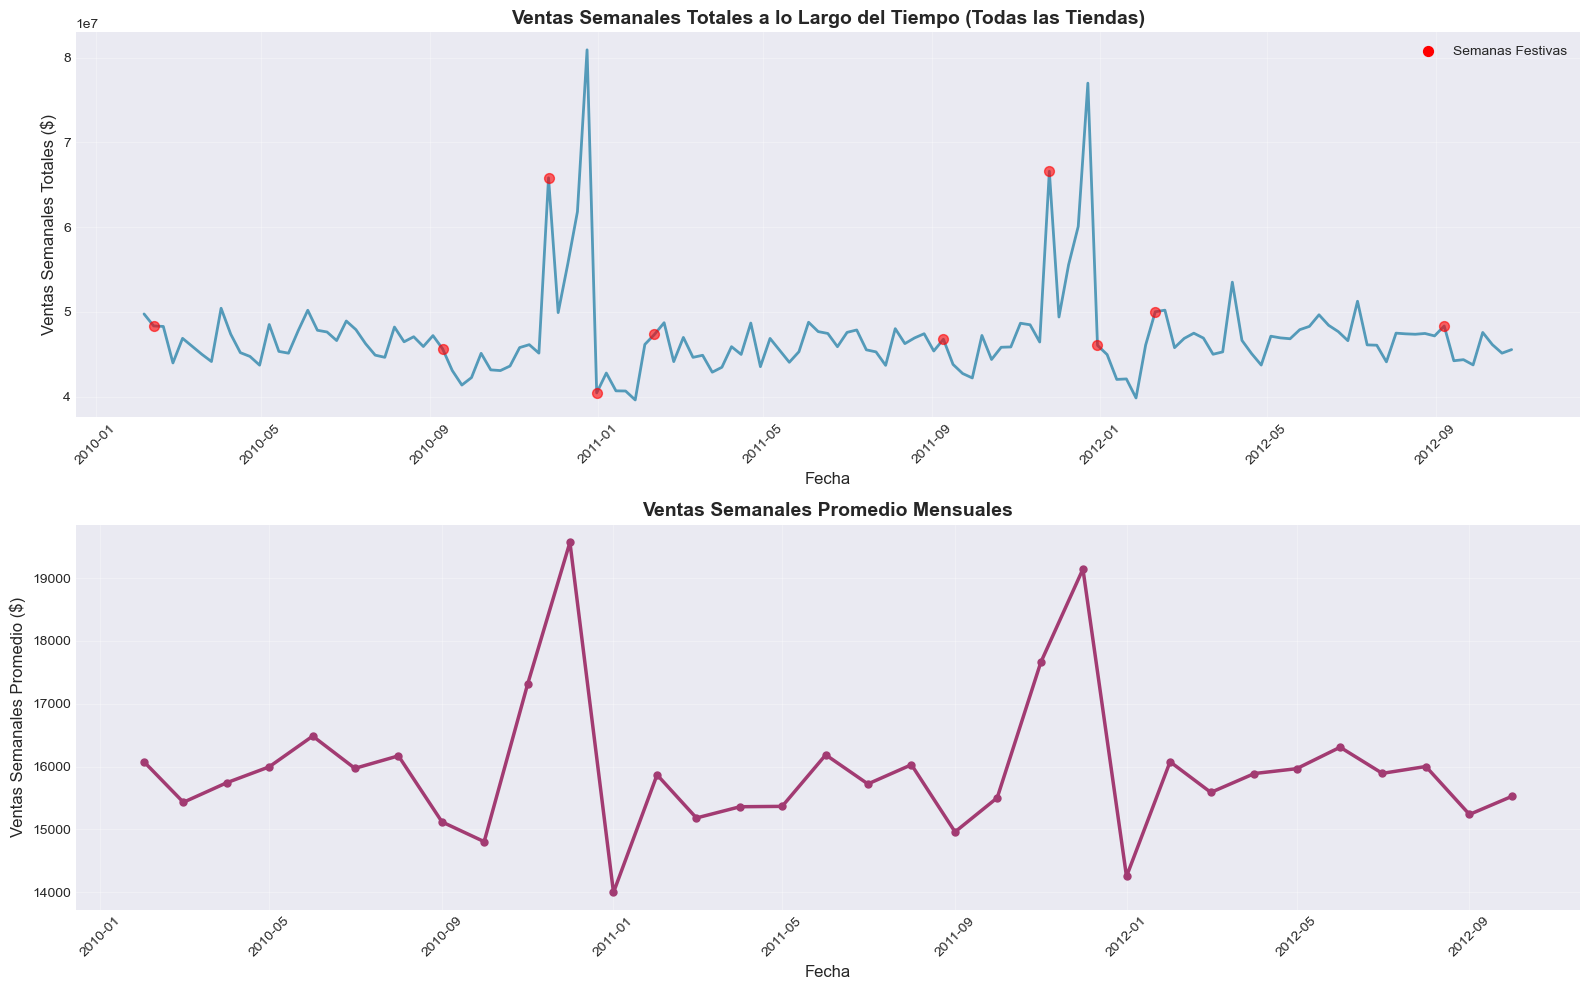

In [24]:
# Agregar ventas semanales a lo largo del tiempo
weekly_sales_trend = train_full.groupby('Date')['Weekly_Sales'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Tendencia general
axes[0].plot(weekly_sales_trend['Date'], weekly_sales_trend['Weekly_Sales'], 
            linewidth=2, color='#2E86AB', alpha=0.8)
axes[0].set_xlabel('Fecha', fontsize=12)
axes[0].set_ylabel('Ventas Semanales Totales ($)', fontsize=12)
axes[0].set_title('Ventas Semanales Totales a lo Largo del Tiempo (Todas las Tiendas)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Marcar semanas festivas
holiday_weeks = train_full[train_full['IsHoliday'] == True]['Date'].unique()
for holiday in holiday_weeks:
    if holiday in weekly_sales_trend['Date'].values:
        sales_value = weekly_sales_trend[weekly_sales_trend['Date'] == holiday]['Weekly_Sales'].values[0]
        axes[0].scatter(holiday, sales_value, color='red', s=50, zorder=5, alpha=0.6)

axes[0].scatter([], [], color='red', s=50, label='Semanas Festivas')
axes[0].legend()

# Ventas promedio mensuales
monthly_sales = train_full.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))

axes[1].plot(monthly_sales['Date'], monthly_sales['Weekly_Sales'], 
            linewidth=2.5, color='#A23B72', marker='o', markersize=5)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].set_ylabel('Ventas Semanales Promedio ($)', fontsize=12)
axes[1].set_title('Ventas Semanales Promedio Mensuales', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

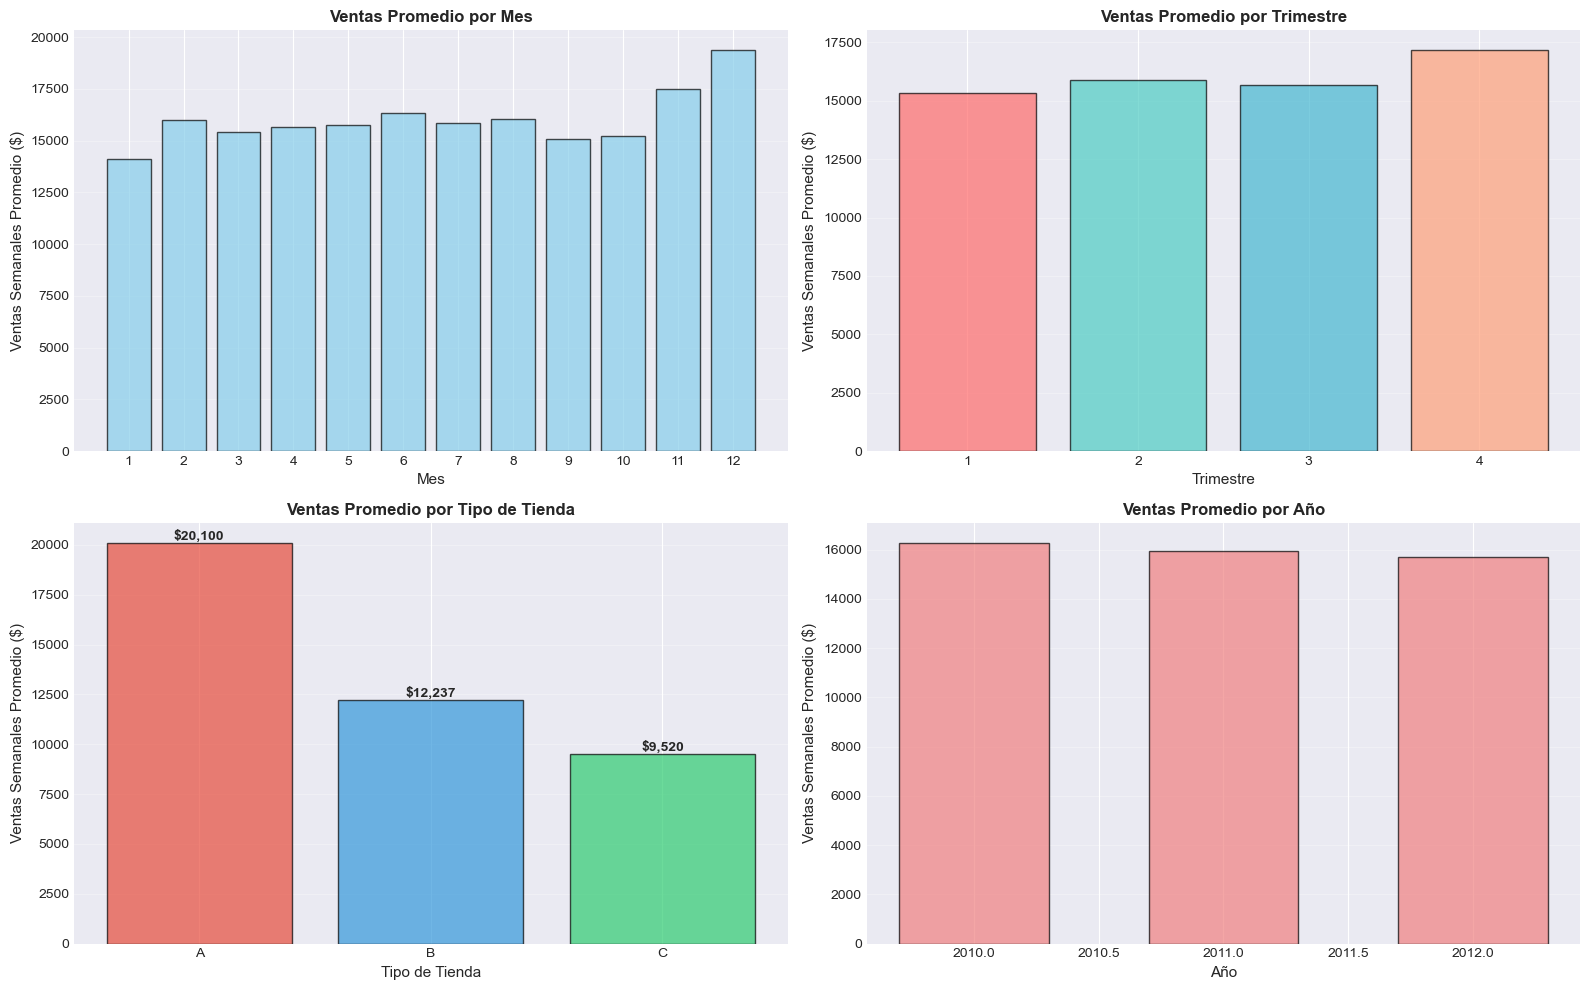

In [25]:
# Análisis de patrones estacionales
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Ventas por Mes
monthly_avg = train_full.groupby('Month')['Weekly_Sales'].mean().sort_index()
axes[0, 0].bar(monthly_avg.index, monthly_avg.values, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Mes', fontsize=11)
axes[0, 0].set_ylabel('Ventas Semanales Promedio ($)', fontsize=11)
axes[0, 0].set_title('Ventas Promedio por Mes', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].grid(alpha=0.3, axis='y')

# Ventas por Trimestre
quarterly_avg = train_full.groupby('Quarter')['Weekly_Sales'].mean().sort_index()
colors_q = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
axes[0, 1].bar(quarterly_avg.index, quarterly_avg.values, color=colors_q, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Trimestre', fontsize=11)
axes[0, 1].set_ylabel('Ventas Semanales Promedio ($)', fontsize=11)
axes[0, 1].set_title('Ventas Promedio por Trimestre', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks([1, 2, 3, 4])
axes[0, 1].grid(alpha=0.3, axis='y')

# Ventas por Tipo de Tienda
store_type_avg = train_full.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
axes[1, 0].bar(store_type_avg.index, store_type_avg.values, color=['#E74C3C', '#3498DB', '#2ECC71'], 
              edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Tipo de Tienda', fontsize=11)
axes[1, 0].set_ylabel('Ventas Semanales Promedio ($)', fontsize=11)
axes[1, 0].set_title('Ventas Promedio por Tipo de Tienda', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

for i, (idx, val) in enumerate(store_type_avg.items()):
    axes[1, 0].text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ventas por Año
yearly_avg = train_full.groupby('Year')['Weekly_Sales'].mean()
axes[1, 1].bar(yearly_avg.index, yearly_avg.values, color='lightcoral', edgecolor='black', alpha=0.7, width=0.6)
axes[1, 1].set_xlabel('Año', fontsize=11)
axes[1, 1].set_ylabel('Ventas Semanales Promedio ($)', fontsize=11)
axes[1, 1].set_title('Ventas Promedio por Año', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2.7 Verificación de Fuga de Datos (Data Leakage)


La fuga de datos (data leakage) ocurre cuando información del futuro o externa al conjunto de entrenamiento contamina el modelo, generando estimaciones de rendimiento artificialmente optimistas. En este análisis se verificó que todas las características (fechas, identificadores de tienda/departamento, días festivos, variables económicas, markdowns y atributos de tienda) representan información que estaría disponible en el momento de realizar predicciones.

La validación temporal confirma que no existe superposición entre los períodos de entrenamiento (2010-02-05 a 2012-11-01) y prueba (2012-11-02 a 2013-07-26), garantizando la integridad del proceso de modelado. Se concluye que el conjunto de datos está libre de fuga de información.


# 3. Procesamiento y Preparación de Datos

En esta sección implementamos un pipeline de procesamiento robusto basado en los hallazgos del análisis exploratorio.


## 3.1 Estrategia de Procesamiento

Basándose en el EDA, aplicaremos las siguientes transformaciones:

**Manejo de valores nulos:**
- MarkDown1-5 (~64-73% nulos): Rellenar con 0 (indica ausencia de promoción)
- CPI y Unemployment: Valores faltantes mínimos, no requieren tratamiento especial

**Codificación de variables categóricas:**
- Type (A, B, C): One-Hot Encoding (3 categorías)
- IsHoliday: Convertir booleano a numérico (0/1)

**Ingeniería de características temporales:**
- Extraer: Year, Month, Week, Quarter de Date
- Crear: DayOfYear para capturar estacionalidad

**Normalización:**
- StandardScaler para: Temperature, Fuel_Price, CPI, Unemployment, Size
- Justificación: Diferentes escalas, mejora convergencia de modelos

**Reducción de dimensionalidad:**
- NO aplicada: Tenemos pocas features (20) y todas son relevantes según correlación


## 3.2 Preparación de Datos

Agregamos la característica temporal DayOfYear que faltaba:


In [26]:
# Agregar característica temporal adicional
train_full['DayOfYear'] = train_full['Date'].dt.dayofyear

print(f"Dataset preparado: {train_full.shape}")
print(f"\nRango temporal:")
print(f"- Inicio: {train_full['Date'].min()}")
print(f"- Fin: {train_full['Date'].max()}")
print(f"- Total columnas: {train_full.shape[1]} (incluye DayOfYear)")

Dataset preparado: (421570, 21)

Rango temporal:
- Inicio: 2010-02-05 00:00:00
- Fin: 2012-10-26 00:00:00
- Total columnas: 21 (incluye DayOfYear)


## 3.3 Pipeline de Procesamiento con Scikit-learn


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Definir grupos de columnas
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
numeric_cols = ['Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 
                'Year', 'Month', 'Week', 'Quarter', 'DayOfYear']
categorical_cols = ['Type']
boolean_cols = ['IsHoliday']

# Pipeline para MarkDowns (imputar con 0, no escalar)
markdown_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

# Pipeline para numéricas (sin imputación, con estandarización)
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Pipeline para categóricas (One-Hot Encoding)
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Transformer completo
preprocessor = ColumnTransformer(
    transformers=[
        ('markdown', markdown_pipeline, markdown_cols),
        ('numeric', numeric_pipeline, numeric_cols),
        ('categorical', categorical_pipeline, categorical_cols),
        ('boolean', 'passthrough', boolean_cols)
    ],
    remainder='drop'
)

print("Pipeline de procesamiento creado")
print(f"\n- Columnas MarkDown: {len(markdown_cols)}")
print(f"- Columnas numéricas: {len(numeric_cols)}")
print(f"- Columnas categóricas: {len(categorical_cols)}")
print(f"- Columnas booleanas: {len(boolean_cols)}")


Pipeline de procesamiento creado

- Columnas MarkDown: 5
- Columnas numéricas: 12
- Columnas categóricas: 1
- Columnas booleanas: 1


## 3.4 División de Datos (Train/Validation)

**Estrategia de división temporal:**

El dataset train.csv (2010-02-05 a 2012-10-26) se divide temporalmente para entrenamiento y validación interna. El test.csv oficial (2012-11-02 a 2013-07-26) se usa al final para predicciones.

**División de train_full:**
- **Train (80%):** 2010-02-05 a 2012-04-06 (335,761 registros)
- **Validation (20%):** 2012-04-13 a 2012-10-26 (85,809 registros)

**Justificación:**
- División temporal respeta la naturaleza de series temporales
- Validation es más reciente, simula predicción del futuro
- 80/20 proporciona suficientes datos para entrenamiento y validación robusta
- test.csv oficial se mantiene separado (no se usa hasta las predicciones finales)


In [28]:
# Ordenar por fecha para división temporal
train_full_sorted = train_full.sort_values('Date').reset_index(drop=True)

# Obtener fechas únicas para división sin superposición
unique_dates = train_full_sorted['Date'].unique()
unique_dates = pd.Series(unique_dates).sort_values().reset_index(drop=True)

# Calcular punto de corte (80/20 split) basado en fechas
n_dates = len(unique_dates)
split_date_idx = int(n_dates * 0.80)
split_date = unique_dates[split_date_idx]

# Dividir datos temporalmente sin superposición
train_data = train_full_sorted[train_full_sorted['Date'] < split_date].copy()
val_data = train_full_sorted[train_full_sorted['Date'] >= split_date].copy()

n = len(train_full_sorted)

print("División de datos (temporal):")
print(f"\nTrain: {len(train_data):,} registros ({len(train_data)/n*100:.1f}%)")
print(f"  - Fecha inicial: {train_data['Date'].min()}")
print(f"  - Fecha final: {train_data['Date'].max()}")

print(f"\nValidation: {len(val_data):,} registros ({len(val_data)/n*100:.1f}%)")
print(f"  - Fecha inicial: {val_data['Date'].min()}")
print(f"  - Fecha final: {val_data['Date'].max()}")

# Separar características y variable objetivo
# Nota: Date no se incluye como feature porque ya extraímos características temporales
# (Year, Month, Week, Quarter, DayOfYear) que son más útiles para el modelo
feature_cols = markdown_cols + numeric_cols + categorical_cols + boolean_cols
target_col = 'Weekly_Sales'

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_val = val_data[feature_cols]
y_val = val_data[target_col]

print("\nForma de los conjuntos:")
print(f"- X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"- X_val: {X_val.shape}, y_val: {y_val.shape}")

print("\nNota: test.csv oficial (115,064 registros) se procesará después del entrenamiento del modelo")

División de datos (temporal):

Train: 335,761 registros (79.6%)
  - Fecha inicial: 2010-02-05 00:00:00
  - Fecha final: 2012-04-06 00:00:00

Validation: 85,809 registros (20.4%)
  - Fecha inicial: 2012-04-13 00:00:00
  - Fecha final: 2012-10-26 00:00:00

Forma de los conjuntos:
- X_train: (335761, 19), y_train: (335761,)
- X_val: (85809, 19), y_val: (85809,)

Nota: test.csv oficial (115,064 registros) se procesará después del entrenamiento del modelo


## 3.5 Aplicar Pipeline de Procesamiento


In [29]:
# Ajustar el preprocessor solo con datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar validation usando el mismo preprocessor -> evitar data leakage
X_val_processed = preprocessor.transform(X_val)

print("Procesamiento completado:")
print(f"- X_train procesado: {X_train_processed.shape}")
print(f"- X_val procesado: {X_val_processed.shape}")

# Obtener nombres de características después del procesamiento
feature_names = []

# MarkDowns
feature_names.extend(markdown_cols)

# Numéricas
feature_names.extend(numeric_cols)

# Categóricas (Type) - OneHot con drop='first' genera n-1 columnas
# Type tiene 3 categorías (A, B, C), drop='first' elimina la primera alfabéticamente
# para evitar multicolinealidad (trampa de variables dummy)
feature_names.extend(['Type_B', 'Type_C'])  # Asumiendo que A es la primera (dropped)

# Booleanas
feature_names.extend(boolean_cols)

print(f"\nTotal de características: {len(feature_names)}")
print(f"Características procesadas: {feature_names}")

Procesamiento completado:
- X_train procesado: (335761, 20)
- X_val procesado: (85809, 20)

Total de características: 20
Características procesadas: ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter', 'DayOfYear', 'Type_B', 'Type_C', 'IsHoliday']


## 3.6 Verificación de Procesamiento

### 3.6.1 Comparación Visual (Antes vs Después)

In [30]:
# Convertir arrays procesados a DataFrames para mejor visualización
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_df = pd.DataFrame(X_val_processed, columns=feature_names)

print("Comparación de los datos Antes vs Después del procesamiento")
print("\n" + "-" * 80)
print("Antes del procesamiento (X_train original):")
print("-" * 80)
print(X_train.head())

print("\n" + "-" * 80)
print("Después del procesamiento (X_train_processed):")
print("-" * 80)
print(X_train_df.head())

print("\n" + "-" * 80)
print("Observaciones:")
print("-" * 80)
print("- Las variables numéricas están normalizadas (media ≈ 0, std ≈ 1)")
print("- MarkDowns: valores nulos imputados con 0")
print("- Type: convertido a Type_B y Type_C (One-Hot Encoding)")
print("- IsHoliday: mantenido como 0/1")

Comparación de los datos Antes vs Después del procesamiento

--------------------------------------------------------------------------------
Antes del procesamiento (X_train original):
--------------------------------------------------------------------------------
   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  Store  Dept    Size  \
0        NaN        NaN        NaN        NaN        NaN      1     1  151315   
1        NaN        NaN        NaN        NaN        NaN     29     5   93638   
2        NaN        NaN        NaN        NaN        NaN     29     6   93638   
3        NaN        NaN        NaN        NaN        NaN     29     7   93638   
4        NaN        NaN        NaN        NaN        NaN     29     8   93638   

   Temperature  Fuel_Price         CPI  Unemployment  Year  Month  Week  \
0        42.31       2.572  211.096358         8.106  2010      2     5   
1        24.36       2.788  131.527903        10.064  2010      2     5   
2        24.36       

### 3.6.2 Verificación Cuantitativa

In [31]:
# 1. Verificar valores nulos
print("1. Valores nulos después del procesamiento:")
print(f"- X_train: {np.isnan(X_train_processed).sum()}")
print(f"- X_val: {np.isnan(X_val_processed).sum()}")

# 2. Verificar normalización (variables numéricas: índices 5-16)
numeric_indices = list(range(5, 17))
print("\n2. Normalización de variables numéricas (media ≈ 0, std ≈ 1):")
print(f"- Media promedio: {X_train_df.iloc[:, numeric_indices].mean().mean():.4f}")
print(f"- Std promedio: {X_train_df.iloc[:, numeric_indices].std().mean():.4f}")

# 3. Verificar One-Hot Encoding
print("\n3. One-Hot Encoding (Type_B, Type_C solo tienen valores 0 o 1):")
print(f"- Type_B valores únicos: {sorted(X_train_df['Type_B'].unique())}")
print(f"- Type_C valores únicos: {sorted(X_train_df['Type_C'].unique())}")

# 4. Verificar distribución de variable objetivo
print("\n4. Distribución de variable objetivo (sin transformar):")
print(f"- Train: Media=${y_train.mean():,.2f}, Std=${y_train.std():,.2f}")
print(f"- Val: Media=${y_val.mean():,.2f}, Std=${y_val.std():,.2f}")


1. Valores nulos después del procesamiento:
- X_train: 0
- X_val: 0

2. Normalización de variables numéricas (media ≈ 0, std ≈ 1):
- Media promedio: 0.0000
- Std promedio: 1.0000

3. One-Hot Encoding (Type_B, Type_C solo tienen valores 0 o 1):
- Type_B valores únicos: [np.float64(0.0), np.float64(1.0)]
- Type_C valores únicos: [np.float64(0.0), np.float64(1.0)]

4. Distribución de variable objetivo (sin transformar):
- Train: Media=$16,032.40, Std=$22,899.40
- Val: Media=$15,781.13, Std=$21,958.22


## 3.7 Exportar Datos Procesados

Guardamos los datos procesados para usarlos en el entrenamiento del modelo (archivo separado):


In [32]:
import pickle
import os

# Crear directorio si no existe
os.makedirs('data', exist_ok=True)

# Guardar datos procesados para entrenamiento
with open('data/processed_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_processed,
        'X_val': X_val_processed,
        'y_train': y_train.values,
        'y_val': y_val.values,
        'feature_names': feature_names,
        'preprocessor': preprocessor  # Para procesar test.csv después
    }, f)

print("✓ Datos procesados guardados en data/processed_data.pkl")
print(f"\nContenido del archivo:")
print(f"- X_train: {X_train_processed.shape}")
print(f"- X_val: {X_val_processed.shape}")
print(f"- y_train: {y_train.shape}")
print(f"- y_val: {y_val.shape}")
print(f"- feature_names: {len(feature_names)} características")
print(f"- preprocessor: Pipeline completo para test.csv")

✓ Datos procesados guardados en data/processed_data.pkl

Contenido del archivo:
- X_train: (335761, 20)
- X_val: (85809, 20)
- y_train: (335761,)
- y_val: (85809,)
- feature_names: 20 características
- preprocessor: Pipeline completo para test.csv


## 3.8 Resumen del Procesamiento

**Transformaciones aplicadas:**

1. **Valores nulos:**
   - MarkDowns: Imputados con 0 (ausencia de promoción)
   - Otras variables: Sin nulos significativos

2. **Codificación categórica:**
   - Type: One-Hot Encoding (A, B, C → 2 columnas)
   - IsHoliday: Booleano conservado (0/1)

3. **Ingeniería de características:**
   - 5 features temporales extraídas de Date (Year, Month, Week, Quarter, DayOfYear)
   - Total: 20 características finales (5 MarkDowns + 12 numéricas + 2 Type + 1 IsHoliday)

4. **Normalización:**
   - StandardScaler aplicado a variables numéricas continuas
   - MarkDowns sin escalar (ya están en escala similar)

**División de datos:**
   - Train: 79.6% (335,761 registros) - 2010-02-05 a 2012-04-06
   - Validation: 20.4% (85,809 registros) - 2012-04-13 a 2012-10-26
   - test.csv oficial: (115,064 registros) - se usará después del entrenamiento
   - División temporal respetada sin superposición de fechas